In [1]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import netCDF4 as nc
import pickle


In [2]:
df_eddies = pd.read_pickle('/srv/scratch/z5297792/SEACOFS_26yr_eddy_dataset/DOPPIO_SEACOFS_26yr_50m_vert_check/df_eddies_50m_vert_checked_processed.pkl')
df_tilt = pd.read_pickle('/srv/scratch/z5297792/SEACOFS_26yr_eddy_dataset/DOPPIO_SEACOFS_26yr_50m_vert_check/df_tilt_vert_checked.pkl')
df_eddies = df_eddies.merge(
    df_tilt[['Eddy', 'Day', 'TiltDis', 'TiltDir']],
    how='left',
    left_on=['Eddy', 'Day'],
    right_on=['Eddy', 'Day']
)
with open('/srv/scratch/z5297792/SEACOFS_26yr_eddy_dataset/DOPPIO_SEACOFS_26yr_50m_vert_check/dic_vert_doppio_50m_vert_checked.pkl', 'rb') as f:
    dic_vert = pickle.load(f)


In [3]:
# Field Data
fname = f'/srv/scratch/z3533156/26year_BRAN2020/outer_avg_01461.nc'
dataset = nc.Dataset(fname)
lon_rho = np.transpose(dataset.variables['lon_rho'], axes=(1, 0))
lat_rho = np.transpose(dataset.variables['lat_rho'], axes=(1, 0))
mask_rho = np.transpose(dataset.variables['mask_rho'], axes=(1, 0))
h = np.transpose(dataset.variables['h'], axes=(1, 0))
# f = np.transpose(dataset.variables['f'], axes=(1, 0))
angle = dataset.variables['angle'][0, 0]
z_r = np.load('/srv/scratch/z5297792/z_r.npy')
z_r = np.transpose(z_r, (1, 2, 0))
def distance(lat1, lon1, lat2, lon2):
    EARTH_RADIUS = 6357
    lat1, lon1, lat2, lon2 = map(np.radians, [lat1, lon1, lat2, lon2])
    dlat, dlon = lat2 - lat1, lon2 - lon1
    a = np.sin(dlat/2)**2 + np.cos(lat1)*np.cos(lat2)*np.sin(dlon/2)**2
    return EARTH_RADIUS * 2 * np.arctan2(np.sqrt(a), np.sqrt(1 - a))
j_mid = lon_rho.shape[1] // 2
i_mid = lon_rho.shape[0] // 2
dx = distance(lat_rho[:-1, j_mid], lon_rho[:-1, j_mid],
              lat_rho[1:, j_mid], lon_rho[1:, j_mid])
dy = distance(lat_rho[i_mid, :-1], lon_rho[i_mid, :-1],
              lat_rho[i_mid, 1:], lon_rho[i_mid, 1:])
x_grid = np.insert(np.cumsum(dx), 0, 0)
y_grid = np.insert(np.cumsum(dy), 0, 0)
X_grid, Y_grid = np.meshgrid(x_grid, y_grid, indexing='ij')


In [35]:
def composite_eddy_velocity(
    eddy,
    dic_vert,
    z_r,
    xlim_km=150,
    nx=100,
    ny=100,
    zmax=1.2e3,
    plot=False,
    zlim=1000,
    levels=20,
    cmap='RdBu_r',
):
    """
    Reconstruct lifetime-mean ESP velocity field for one eddy.

    Returns
    -------
    X, Y, z_grid, U_comp, V_comp
        X, Y in metres, z_grid in metres, U/V in m s^-1.
        U_comp and V_comp have shape (nx, ny, nz).
    """

    x = np.linspace(-xlim_km, xlim_km, nx) * 1e3
    y = np.linspace(-xlim_km, xlim_km, ny) * 1e3

    z_grid = np.insert(np.abs(z_r[150, 150, 1:]), 0, 0)
    z_grid = z_grid[z_grid < zmax]

    X, Y = np.meshgrid(x, y, indexing='ij')

    nz = len(z_grid)

    U_days = []
    V_days = []

    for day, df in dic_vert[f'Eddy{eddy}'].items():

        df = df.copy().sort_values('z')

        # shift centres relative to surface centre for this day
        df['xc'] -= df['xc'].iloc[0]
        df['yc'] -= df['yc'].iloc[0]

        U = np.zeros((nx, ny, nz))
        V = np.zeros((nx, ny, nz))

        for _, data in df.iterrows():

            k = np.argmin(np.abs(z_grid - abs(data.Depth)))

            dx = X - data.xc * 1e3
            dy = Y - data.yc * 1e3

            q11 = data.Q[0, 0]
            q12 = data.Q[0, 1]
            q22 = data.Q[1, 1]

            rho2 = q11*dx**2 + 2*q12*dx*dy + q22*dy**2
            fac = data.Omega * np.exp(-rho2 / (data.Rc * 1e3)**2)

            U[:, :, k] = -fac * (q12*dx + q22*dy)
            V[:, :, k] =  fac * (q11*dx + q12*dy)

        U_days.append(U)
        V_days.append(V)

    U_comp = np.mean(U_days, axis=0)
    V_comp = np.mean(V_days, axis=0)

    if not plot:
        return X, Y, z_grid, U_comp, V_comp

    ix0 = np.argmin(np.abs(x))
    iy0 = np.argmin(np.abs(y))

    vmax = np.nanmax(np.abs([U_comp, V_comp]))

    fig, axs = plt.subplots(
        1, 2,
        figsize=(11, 4),
        sharey=True,
        constrained_layout=True
    )

    # zonal section: x-z at y = 0, perpendicular velocity = V
    m0 = axs[0].contourf(
        x / 1e3,
        z_grid,
        V_comp[:, iy0, :].T,
        cmap=cmap,
        vmin=-vmax,
        vmax=vmax,
        levels=levels,
        extend='both'
    )

    axs[0].contour(
        x / 1e3,
        z_grid,
        V_comp[:, iy0, :].T,
        levels=[0],
        colors='k',
        linewidths=2
    )

    axs[0].set_title('Zonal: $v$')
    axs[0].set_xlabel('x (km)')
    axs[0].set_ylabel('Depth (m)')
    axs[0].invert_yaxis()
    axs[0].axvline(0, color='k', lw=0.8)
    axs[0].set_ylim(zlim, 0)

    # meridional section: y-z at x = 0, perpendicular velocity = U
    axs[1].contourf(
        y / 1e3,
        z_grid,
        U_comp[ix0, :, :].T,
        cmap=cmap,
        vmin=-vmax,
        vmax=vmax,
        levels=levels,
        extend='both'
    )

    axs[1].contour(
        y / 1e3,
        z_grid,
        U_comp[ix0, :, :].T,
        levels=[0],
        colors='k',
        linewidths=2
    )

    axs[1].set_title('Meridional: $u$')
    axs[1].set_xlabel('y (km)')
    axs[1].axvline(0, color='k', lw=0.8)
    axs[1].set_ylim(zlim, 0)

    cbar = fig.colorbar(m0, ax=axs, location='right', shrink=0.9)
    cbar.set_label('(m s$^{-1}$)')

    fig.suptitle(f'Eddy {eddy}')

    return X, Y, z_grid, U_comp, V_comp, fig, axs
    

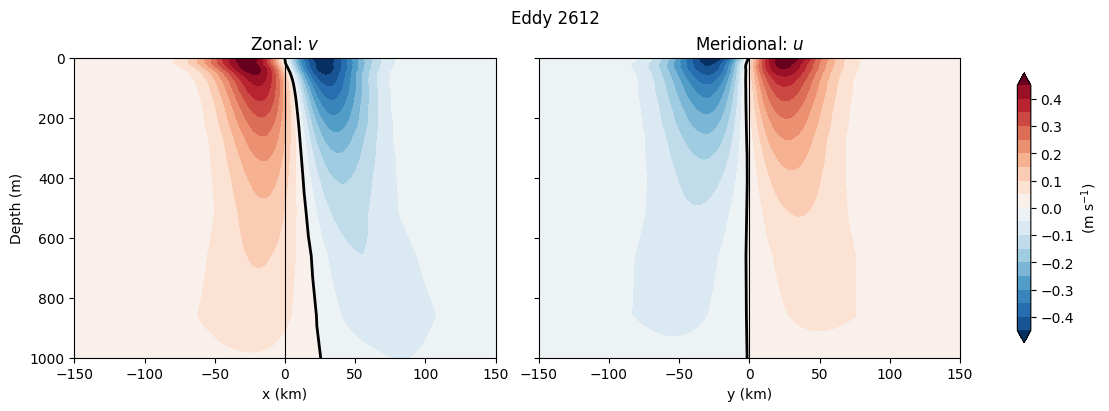

In [40]:
_ = composite_eddy_velocity(
    eddy=2612,
    dic_vert=dic_vert,
    z_r=z_r,
    plot=True
)